### STA 4724: Homework 5 - Due Monday, Nov 24  
**Instructions**: Finsih the assign by directly answering the question or finishing the code in this Jupyter notebook. 

After you finish, submit the saved notebook to webcourses.

**Your name:**  Gino Benitez                   

**Your ID:** 5110519

## Question 1: Image Denoise via PCA
Many medical images, such as MRI, are low-rank. Medical image denoising is an active research field. A simple PCA won't achieve state-of-the-art denoising result, yet it is one of the simplest methods that give us some level of denoising.

**(a)** Read the noisy MRI image.

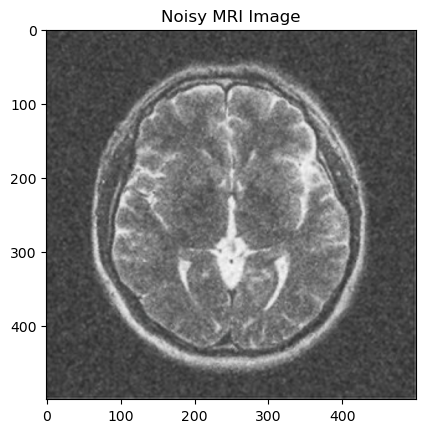

Image shape: (500, 500, 3)


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read the noisy MRI image
A_noisy = cv2.imread('MRI_noisy.png')

# Display the image
plt.imshow(A_noisy)
plt.title('Noisy MRI Image')
plt.show()

# Print the shape
print(f"Image shape: {A_noisy.shape}")


Based on how you read the image. If you read the image as a color image (that is, the data matrix has RGB color channels), then convert it to a grayscale image. Write "N/A" if you directly read it as a grayscale image.

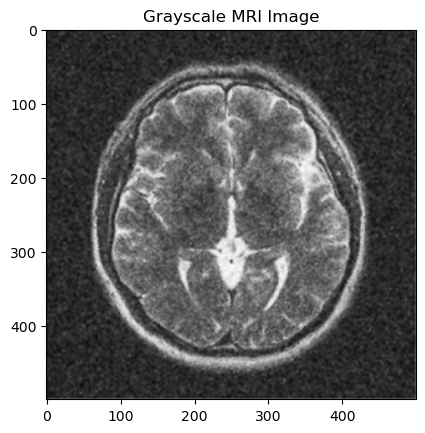

Grayscale image shape: (500, 500)


In [2]:
# Convert to grayscale by taking the mean across color channels
A_gray = np.mean(A_noisy, axis=2)

# Display the grayscale image
plt.imshow(A_gray, cmap='gray')
plt.title('Grayscale MRI Image')
plt.show()

print(f"Grayscale image shape: {A_gray.shape}")


**(b)** Print the images denoised/reconstructed with rank $r = 1, 2, 3, 5, 10, 20$.

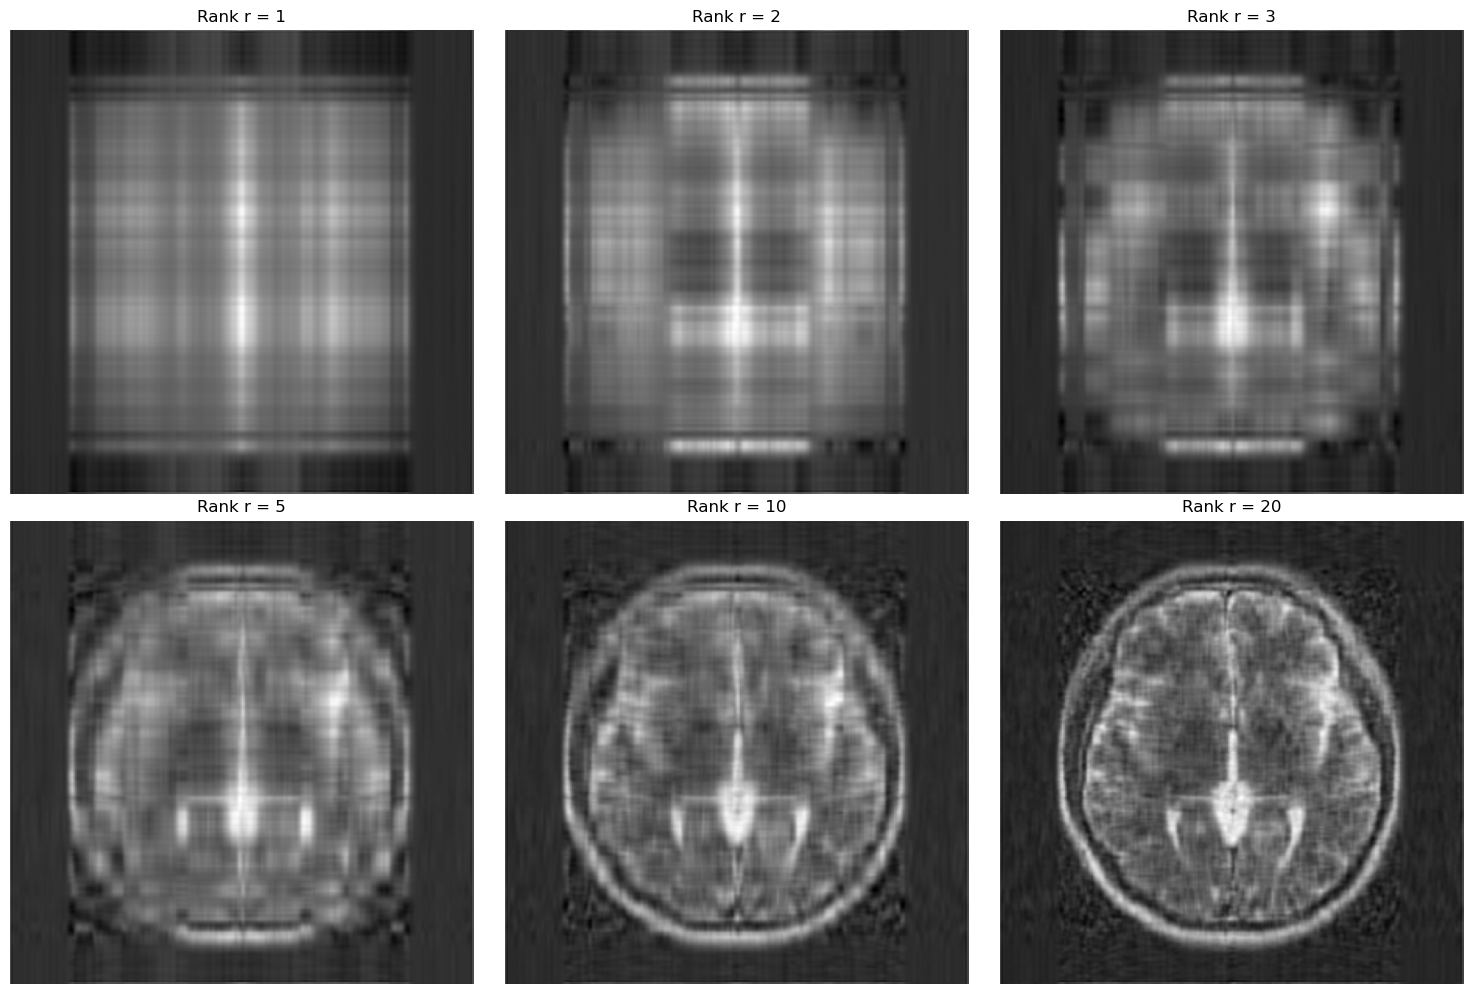

In [3]:
from sklearn import decomposition
import matplotlib.ticker as tic

# Ranks to test
ranks = [1, 2, 3, 5, 10, 20]

fig = plt.figure(figsize=(15, 10))

for i, rank in enumerate(ranks):
    # Set the number of components
    pca = decomposition.PCA(n_components=rank)
    pca.fit(A_gray)
    
    # Reconstruct the image
    A_reconstructed = pca.inverse_transform(pca.transform(A_gray))
    
    # Make subplot
    ax = fig.add_subplot(2, 3, i+1, frame_on=False)
    
    # Removing ticks
    ax.xaxis.set_major_locator(tic.NullLocator())
    ax.yaxis.set_major_locator(tic.NullLocator())
    
    plt.imshow(A_reconstructed, cmap='gray')
    plt.title(f'Rank r = {rank}')
    
plt.tight_layout()
plt.show()


**(c)** Read the clear MRI image, convert it to grayscale if needed. 

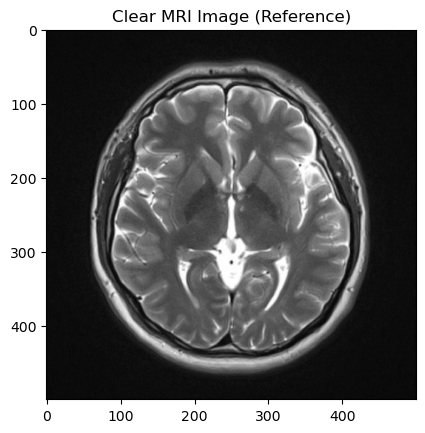

Clear image shape: (500, 500)


In [4]:
# Read the clear MRI image
A_clear = cv2.imread('MRI_clear.png')

# Convert to grayscale
A_clear_gray = np.mean(A_clear, axis=2)

# Display the clear image
plt.imshow(A_clear_gray, cmap='gray')
plt.title('Clear MRI Image (Reference)')
plt.show()

print(f"Clear image shape: {A_clear_gray.shape}")


Use the clear image as your reference to find the best rank for this denoising task. 

Hint1: Use a loop to try different ranks.

Hint2: The best noised image should be the one most similar to the clear image, which means the different between the images is smaller. Use Frobenius norm.


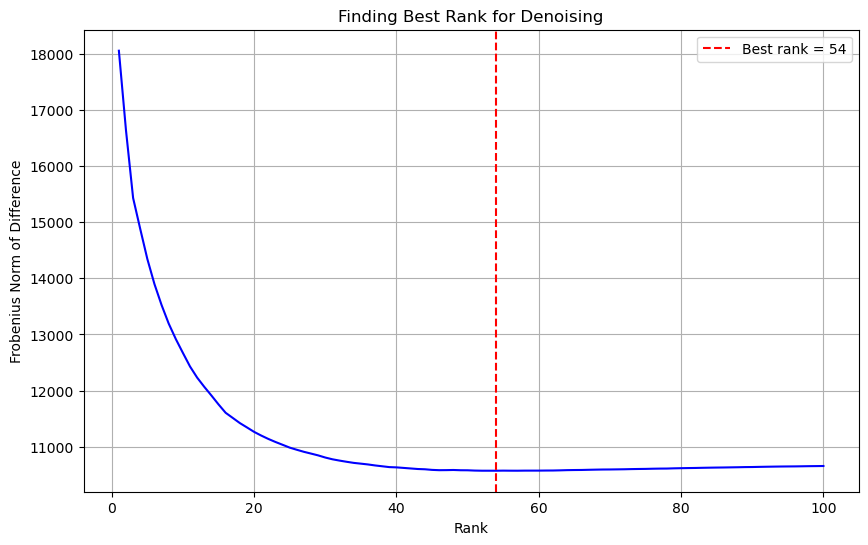

Best rank: 54
Minimum Frobenius norm: 10572.37


In [5]:
# Try different ranks and compute Frobenius norm difference
ranks_to_test = range(1, 101)
frobenius_norms = []

for rank in ranks_to_test:
    # Apply PCA with rank r
    pca = decomposition.PCA(n_components=rank)
    pca.fit(A_gray)
    
    # Reconstruct the image
    A_reconstructed = pca.inverse_transform(pca.transform(A_gray))
    
    # Calculate Frobenius norm of the difference
    diff = A_clear_gray - A_reconstructed
    frob_norm = np.linalg.norm(diff, 'fro')
    frobenius_norms.append(frob_norm)

# Find the rank with minimum Frobenius norm
best_rank = ranks_to_test[np.argmin(frobenius_norms)]

# Plot the Frobenius norm vs rank
plt.figure(figsize=(10, 6))
plt.plot(ranks_to_test, frobenius_norms, 'b-')
plt.axvline(x=best_rank, color='r', linestyle='--', label=f'Best rank = {best_rank}')
plt.xlabel('Rank')
plt.ylabel('Frobenius Norm of Difference')
plt.title('Finding Best Rank for Denoising')
plt.legend()
plt.grid(True)
plt.show()

print(f"Best rank: {best_rank}")
print(f"Minimum Frobenius norm: {min(frobenius_norms):.2f}")


What's the best rank for this denoising task?

**Answer**: The best rank will be shown in the output of the cell above. Run all cells to find it.

## Question 2: Support Vector Machine

you will use support vector approaches in order to predict whether a given car gets high or low gas mileage based on the
*Auto* dataset.

**(a)** Load the dataset.

In [6]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Load the Auto dataset
auto_df = pd.read_csv('Auto.csv')

# Display first few rows
print(auto_df.head())
print(f"\nDataset shape: {auto_df.shape}")
print(f"\nColumn names: {auto_df.columns.tolist()}")


   Unnamed: 0   mpg  cylinders  displacement  horsepower  weight  \
0           1  18.0          8         307.0         130    3504   
1           2  15.0          8         350.0         165    3693   
2           3  18.0          8         318.0         150    3436   
3           4  16.0          8         304.0         150    3433   
4           5  17.0          8         302.0         140    3449   

   acceleration  year  origin                       name  
0          12.0    70       1  chevrolet chevelle malibu  
1          11.5    70       1          buick skylark 320  
2          11.0    70       1         plymouth satellite  
3          12.0    70       1              amc rebel sst  
4          10.5    70       1                ford torino  

Dataset shape: (392, 10)

Column names: ['Unnamed: 0', 'mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin', 'name']


Create a binary variable that takes on a 1 for cars with gas mileage above the median, and a 0 for cars with gas mileage below the median. 

Hint: You need to find the median first.

In [7]:
# Calculate the median of mpg (miles per gallon)
mpg_median = auto_df['mpg'].median()
print(f"Median mpg: {mpg_median}")

# Create binary variable: 1 for above median, 0 for below median
auto_df['mpg_high'] = (auto_df['mpg'] > mpg_median).astype(int)

# Check the distribution
print(f"\nDistribution of mpg_high:")
print(auto_df['mpg_high'].value_counts())

# Prepare features (X) and target (y)
# Drop non-numeric columns and the original mpg column
X = auto_df.drop(['mpg', 'mpg_high', 'name'], axis=1, errors='ignore')
y = auto_df['mpg_high']

print(f"\nFeatures shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")


Median mpg: 22.75

Distribution of mpg_high:
mpg_high
0    196
1    196
Name: count, dtype: int64

Features shape: (392, 8)
Features: ['Unnamed: 0', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']


**(b)** Fit a support vector classifier to the data with various parameters of the cars, in order to predict whether a car gets high or low gas mileage. 

In [8]:
# Standardize the features (important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit SVM with linear kernel using different cost values
cost_values = [0.01, 0.1, 1, 10, 100]

print("Linear SVM with different cost values:\n")
print(f"{'Cost':<10} {'CV Accuracy':<15} {'CV Error':<15}")
print("-" * 40)

for cost in cost_values:
    # Create SVM classifier (C is the cost parameter)
    svm_linear = SVC(kernel='linear', C=cost, random_state=42)
    
    # Perform 10-fold cross-validation
    cv_scores = cross_val_score(svm_linear, X_scaled, y, cv=10, scoring='accuracy')
    
    # Calculate mean accuracy and error
    cv_accuracy = cv_scores.mean()
    cv_error = 1 - cv_accuracy
    
    print(f"{cost:<10} {cv_accuracy:<15.4f} {cv_error:<15.4f}")


Linear SVM with different cost values:

Cost       CV Accuracy     CV Error       
----------------------------------------
0.01       0.9004          0.0996         
0.1        0.8904          0.1096         
1          0.9033          0.0967         
10         0.9033          0.0967         
100        0.8957          0.1043         


Report the cross-validation errors associated with different values of *cost*.

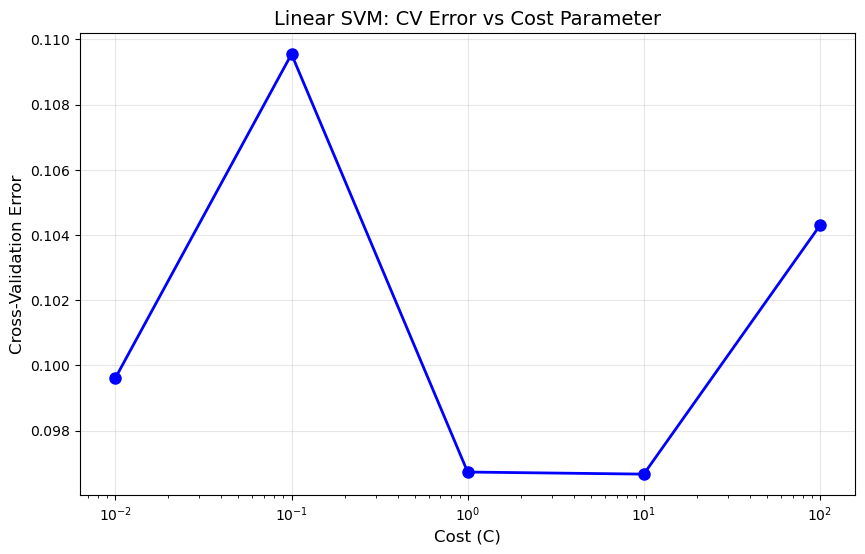


Best cost: 10
Lowest CV error: 0.0967


In [9]:
# Visualize the cross-validation errors
cost_values = [0.01, 0.1, 1, 10, 100]
cv_errors = []

for cost in cost_values:
    svm_linear = SVC(kernel='linear', C=cost, random_state=42)
    cv_scores = cross_val_score(svm_linear, X_scaled, y, cv=10, scoring='accuracy')
    cv_error = 1 - cv_scores.mean()
    cv_errors.append(cv_error)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(cost_values, cv_errors, 'bo-', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Cost (C)', fontsize=12)
plt.ylabel('Cross-Validation Error', fontsize=12)
plt.title('Linear SVM: CV Error vs Cost Parameter', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Find best cost
best_idx = np.argmin(cv_errors)
print(f"\nBest cost: {cost_values[best_idx]}")
print(f"Lowest CV error: {cv_errors[best_idx]:.4f}")


**(c)** Now repeat (b), this time using SVMs with polynomial kernel, with different values of degree *d* and *cost*.

In [11]:
# Test SVM with polynomial kernel with different degrees and costs
degrees = [2, 3, 4]
cost_values = [0.1, 1, 10, 100]

print("Polynomial SVM with different degrees and costs:\n")
print(f"{'Degree':<10} {'Cost':<10} {'CV Accuracy':<15} {'CV Error':<15}")
print("-" * 50)

results = []

for degree in degrees:
    for cost in cost_values:
        # Create SVM with polynomial kernel
        svm_poly = SVC(kernel='poly', degree=degree, C=cost, random_state=42)
        
        # Perform 10-fold cross-validation
        cv_scores = cross_val_score(svm_poly, X_scaled, y, cv=10, scoring='accuracy')
        
        # Calculate mean accuracy and error
        cv_accuracy = cv_scores.mean()
        cv_error = 1 - cv_accuracy
        
        results.append({
            'degree': degree,
            'cost': cost,
            'accuracy': cv_accuracy,
            'error': cv_error
        })
        
        print(f"{degree:<10} {cost:<10} {cv_accuracy:<15.4f} {cv_error:<15.4f}")

# Find best combination
best_result = min(results, key=lambda x: x['error'])
print(f"\nBest configuration:")
print(f"  Degree: {best_result['degree']}")
print(f"  Cost: {best_result['cost']}")
print(f"  CV Error: {best_result['error']:.4f}")
print(f"  CV Accuracy: {best_result['accuracy']:.4f}")


Polynomial SVM with different degrees and costs:

Degree     Cost       CV Accuracy     CV Error       
--------------------------------------------------
2          0.1        0.6126          0.3874         
2          1          0.6739          0.3261         
2          10         0.8092          0.1908         
2          100        0.7835          0.2165         
3          0.1        0.7956          0.2044         
3          1          0.8548          0.1452         
3          10         0.8931          0.1069         
3          100        0.8906          0.1094         
4          0.1        0.6660          0.3340         
4          1          0.6798          0.3202         
4          10         0.7357          0.2643         
4          100        0.8045          0.1955         

Best configuration:
  Degree: 3
  Cost: 10
  CV Error: 0.1069
  CV Accuracy: 0.8931
